In [23]:
!pip install statsmodels

In [24]:
import glob
import os
import sqlite3
import pandas as pd

raw_data_path = "C:/Users/nikol/Desktop/Olist_Churn_Project/Raw_Data/archive/"
db_path = "C:/Users/nikol/Desktop/Olist_Churn_Project/olist_ecommerce.db"

# Creation of the database file
conn = sqlite3.connect(db_path)

# Loading CSVs into SQL tables
csv_files = glob.glob(os.path.join(raw_data_path, "*.csv"))

for file in csv_files:
  table_name = (
      os.path.basename(file)
      .replace("olist_", "")
      .replace("_dataset.csv", "")
      .replace(".csv", "")
  )

  df = pd.read_csv(file)
  df.to_sql(table_name, conn, if_exists="replace", index=False)
  print(
      f" Loaded SQL table '{table_name}' ({df.shape[0]} rows, {df.shape[1]}"
      " columns)"
  )

print("\n Database ready.")

 Loaded SQL table 'customers' (99441 rows, 5 columns)
 Loaded SQL table 'geolocation' (1000163 rows, 5 columns)
 Loaded SQL table 'orders' (99441 rows, 8 columns)
 Loaded SQL table 'order_items' (112650 rows, 7 columns)
 Loaded SQL table 'order_payments' (103886 rows, 5 columns)
 Loaded SQL table 'order_reviews' (99224 rows, 7 columns)
 Loaded SQL table 'products' (32951 rows, 9 columns)
 Loaded SQL table 'sellers' (3095 rows, 4 columns)
 Loaded SQL table 'product_category_name_translation' (71 rows, 2 columns)

 Database ready.


In [25]:
# Check of total orders vs. unique customers
query = """
SELECT 
    COUNT(o.order_id) AS total_orders,
    COUNT(DISTINCT c.customer_unique_id) AS unique_customers,
    ROUND(CAST(COUNT(o.order_id) AS FLOAT) / COUNT(DISTINCT c.customer_unique_id), 3) AS orders_per_customer
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered';
"""

df_summary = pd.read_sql_query(query, conn)
display(df_summary)

,total_orders,unique_customers,orders_per_customer
0,96478,93358,1.033


In [26]:
econometric_query = """
WITH order_level_metrics AS (
    SELECT 
        o.order_id,
        c.customer_unique_id,
        c.customer_state,
        strftime('%Y', o.order_purchase_timestamp) AS purchase_year,
        
        -- 1. Delivery Delay in Days (Actual Delivery Date minus Estimated Date)
        ROUND(julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date), 1) AS delivery_delay_days,
        
        -- 2. Actual Delivery Time in Days (Delivered Date minus Purchase Date)
        ROUND(julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp), 1) AS delivery_time_days,
        
        -- 3. Financials from order_items (Price + Shipping)
        SUM(oi.price) AS order_price,
        SUM(oi.freight_value) AS freight_value,
        COUNT(oi.order_item_id) AS items_count,
        
        -- 4. Payment Installments & Method
        MAX(op.payment_installments) AS installments,
        MAX(CASE WHEN op.payment_type = 'credit_card' THEN 1 ELSE 0 END) AS paid_credit_card,
        
        -- 5. Customer Review Score (1 to 5 stars)
        AVG(r.review_score) AS review_score

    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    LEFT JOIN order_payments op ON o.order_id = op.order_id
    LEFT JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
    GROUP BY o.order_id, c.customer_unique_id, c.customer_state, purchase_year
)

-- Aggregate to the Unique Customer Level for Econometric Analysis
SELECT 
    customer_unique_id,
    customer_state AS state_fe,
    MIN(purchase_year) AS cohort_year,
    
    -- Dependent Variables (Outcomes)
    CASE WHEN COUNT(order_id) > 1 THEN 1 ELSE 0 END AS repeat_buyer,
    CASE WHEN AVG(review_score) <= 2 THEN 1 ELSE 0 END AS dissatisfied_churn,
    SUM(order_price) AS total_spend,
    
    -- Explanatory Variables (Regressors)
    MAX( CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END ) AS experienced_delay,
    AVG(delivery_time_days) AS avg_delivery_days,
    SUM(freight_value) / SUM(order_price) AS freight_to_price_ratio,
    MAX(installments) AS max_installments,
    MAX(paid_credit_card) AS credit_card_user,
    AVG(review_score) AS avg_review_score

FROM order_level_metrics
GROUP BY customer_unique_id
HAVING total_spend > 0 AND avg_delivery_days >= 0;
"""

# Load the SQL result into a pandas DataFrame for econometrics
df_econ = pd.read_sql_query(econometric_query, conn)
print(f" Analytical Sample Constructed: {df_econ.shape[0]} unique customers.")
display(df_econ.head())

 Analytical Sample Constructed: 93350 unique customers.


,customer_unique_id,state_fe,cohort_year,repeat_buyer,dissatisfied_churn,total_spend,experienced_delay,avg_delivery_days,freight_to_price_ratio,max_installments,credit_card_user,avg_review_score
0,0000366f3b9a7992bf8c76cfdf3221e2,SP,2018,0,0,129.90,0,6.4,0.092379,8.0,1,5.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,SP,2018,0,0,18.90,0,3.3,0.438624,1.0,1,4.0
2,0000f46a3911fa3c0805444483337064,SC,2017,0,0,69.00,0,25.7,0.249565,8.0,1,3.0
3,0000f6ccb0745a6a4b88665a16c9f078,PA,2017,0,0,25.99,0,20.0,0.678338,4.0,1,4.0
4,0004aac84e0df4da2b147fca70cf8255,SP,2017,0,0,180.00,0,13.1,0.093833,6.0,1,5.0


In [27]:
import numpy as np
import statsmodels.formula.api as smf

# Creation of Log Spend
df_econ['log_spend'] = np.log(df_econ['total_spend'])

# Summary Statistics of core variables
cols_to_summarize = [
    'repeat_buyer',
    'dissatisfied_churn',
    'total_spend',
    'log_spend',
    'experienced_delay',
    'avg_delivery_days',
    'freight_to_price_ratio',
    'max_installments',
    'credit_card_user',
]
display(df_econ[cols_to_summarize].describe().round(3))

# Model 1: Linear Probability Model (LPM) for Dissatisfied Churn (1-2 Star Review)
# Controlling for State Fixed Effects C(state_fe) and Cohort Year Fixed Effects C(cohort_year)
lpm_dissatisfied = smf.ols(
    formula=(
        'dissatisfied_churn ~ experienced_delay + avg_delivery_days +'
        ' freight_to_price_ratio + credit_card_user + C(state_fe) +'
        ' C(cohort_year)'
    ),
    data=df_econ,
).fit(cov_type='HC1')

# Core coefficients 
print('=== LPM Results: Probability of Customer Dissatisfaction / Churn ===')
core_vars = [
    'Intercept',
    'experienced_delay',
    'avg_delivery_days',
    'freight_to_price_ratio',
    'credit_card_user',
]
summary_table = pd.DataFrame({
    'Coefficient': lpm_dissatisfied.params[core_vars].round(4),
    'Robust Std. Err.': lpm_dissatisfied.bse[core_vars].round(4),
    't-stat': lpm_dissatisfied.tvalues[core_vars].round(2),
    'p-value': lpm_dissatisfied.pvalues[core_vars].round(4),
})
display(summary_table)
print(
    f'Observations: {int(lpm_dissatisfied.nobs)} | R-squared:'
    f' {lpm_dissatisfied.rsquared:.4f}'
)

,repeat_buyer,dissatisfied_churn,total_spend,log_spend,experienced_delay,avg_delivery_days,freight_to_price_ratio,max_installments,credit_card_user
count,93350.000,93350.000,93350.000,93350.000,93350.000,93350.000,93350.000,93349.000,93350.000
mean,0.030,0.126,148.637,4.496,0.083,12.567,0.306,2.938,0.772
std,0.171,0.332,245.413,0.951,0.275,9.546,0.309,2.722,0.420
min,0.000,0.000,0.850,-0.163,0.000,0.500,0.000,0.000,0.000
25%,0.000,0.000,48.900,3.890,0.000,6.800,0.132,1.000,1.000
50%,0.000,0.000,89.900,4.499,0.000,10.200,0.224,2.000,1.000
75%,0.000,0.000,159.900,5.075,0.000,15.700,0.378,4.000,1.000
max,1.000,1.000,13440.000,9.506,1.000,209.600,21.447,24.000,1.000


=== LPM Results: Probability of Customer Dissatisfaction / Churn ===


,Coefficient,Robust Std. Err.,t-stat,p-value
Intercept,-0.0050,0.0437,-0.11,0.9097
experienced_delay,0.3139,0.0073,42.74,0.0000
avg_delivery_days,0.0058,0.0003,21.72,0.0000
freight_to_price_ratio,0.0082,0.0035,2.34,0.0194
credit_card_user,0.0093,0.0024,3.83,0.0001


Observations: 93350 | R-squared: 0.1452


In [28]:
df_clean = df_econ.dropna(subset=['max_installments']).copy()

# Creation of binary indicator for top 20% spenders
spend_80th_cutoff = df_clean['total_spend'].quantile(0.80)
df_clean['top_20_spender'] = np.where(
    df_clean['total_spend'] >= spend_80th_cutoff, 1, 0
)

# Model 2: Log-Linear OLS ("Mincerian" Spending Equation)
ols_spend = smf.ols(
    formula=(
        'log_spend ~ credit_card_user + max_installments + repeat_buyer +'
        ' avg_delivery_days + C(state_fe) + C(cohort_year)'
    ),
    data=df_clean,
).fit(cov_type='HC1')

# Model 3: Distributional LPM for Top 20% Spenders
lpm_top20 = smf.ols(
    formula=(
        'top_20_spender ~ credit_card_user + max_installments + repeat_buyer +'
        ' avg_delivery_days + C(state_fe) + C(cohort_year)'
    ),
    data=df_clean,
).fit(cov_type='HC1')

spend_vars = [
    'Intercept',
    'credit_card_user',
    'max_installments',
    'repeat_buyer',
    'avg_delivery_days',
]
comparison_df = pd.DataFrame({
    'OLS: Log Spend (Coef)': ols_spend.params[spend_vars].round(4),
    'OLS: Robust SE': ols_spend.bse[spend_vars].round(4),
    'OLS: p-value': ols_spend.pvalues[spend_vars].round(4),
    'LPM: Top 20% Spender (Coef)': lpm_top20.params[spend_vars].round(4),
    'LPM: Robust SE': lpm_top20.bse[spend_vars].round(4),
    'LPM: p-value': lpm_top20.pvalues[spend_vars].round(4),
})

print(
    f'=== Spending Models (80th Percentile Cutoff: {spend_80th_cutoff:.2f} BRL)'
    ' ==='
)
display(comparison_df)
print(
    f'OLS R-squared: {ols_spend.rsquared:.4f} | LPM Top 20% R-squared:'
    f' {lpm_top20.rsquared:.4f}'
)

# Robustness Check: Comparing Linear Probability Model (LPM) vs. Logit Marginal Effects
logit_model = smf.logit(
    formula=(
        'dissatisfied_churn ~ experienced_delay + avg_delivery_days +'
        ' freight_to_price_ratio + credit_card_user'
    ),
    data=df_clean,
).fit(disp=False)

# Calculation of Average Marginal Effects (AME) for Logit
logit_ame = logit_model.get_margeff(at='overall', dummy=True).summary_frame()

# Comparison of LPM Coefficients vs. Logit Marginal Effects
vars_to_compare = [
    'experienced_delay',
    'avg_delivery_days',
    'freight_to_price_ratio',
    'credit_card_user',
]
robustness_df = pd.DataFrame({
    'LPM Coefficient (Fixed Effects)': (
        lpm_dissatisfied.params[vars_to_compare].round(4)
    ),
    'Logit Marginal Effect': (
        logit_ame.loc[vars_to_compare, 'dy/dx'].round(4)
    ),
    'Logit SE': logit_ame.loc[vars_to_compare, 'Std. Err.'].round(4),
    'Logit p-value': logit_ame.loc[vars_to_compare, 'Pr(>|z|)'].round(4),
})

print(
    '=== Robustness Check: LPM vs. Logit Average Marginal Effects (AME) ==='
)
display(robustness_df)

=== Spending Models (80th Percentile Cutoff: 187.00 BRL) ===


,OLS: Log Spend (Coef),OLS: Robust SE,OLS: p-value,LPM: Top 20% Spender (Coef),LPM: Robust SE,LPM: p-value
Intercept,4.2398,0.1291,0.0,0.2079,0.0579,0.0003
credit_card_user,-0.1575,0.0077,0.0,-0.0661,0.0029,0.0000
max_installments,0.1454,0.0011,0.0,0.0503,0.0006,0.0000
repeat_buyer,0.7036,0.0153,0.0,0.2896,0.0092,0.0000
avg_delivery_days,0.0049,0.0003,0.0,0.0011,0.0002,0.0000


OLS R-squared: 0.1871 | LPM Top 20% R-squared: 0.1288
=== Robustness Check: LPM vs. Logit Average Marginal Effects (AME) ===


,LPM Coefficient (Fixed Effects),Logit Marginal Effect,Logit SE,Logit p-value
experienced_delay,0.3139,0.2498,0.0074,0.0000
avg_delivery_days,0.0058,0.0038,0.0001,0.0000
freight_to_price_ratio,0.0082,0.0035,0.0031,0.2498
credit_card_user,0.0093,0.0074,0.0023,0.0017


 Image successfully saved to: C:/Users/nikol/Desktop/Olist_Churn_Project/olist_econometric_findings.png


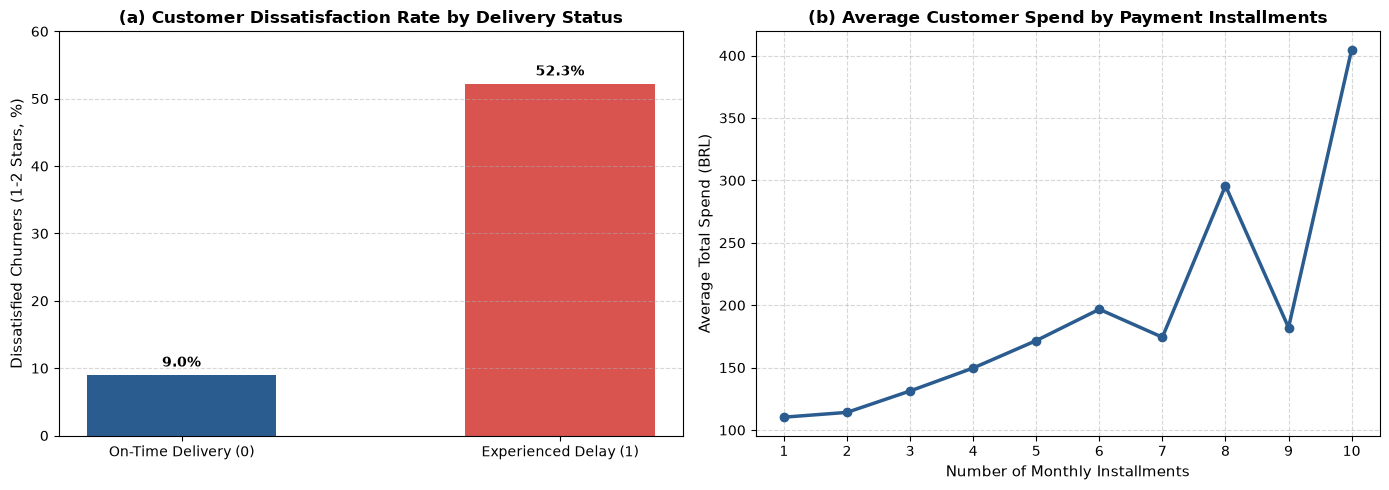

In [29]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dissatisfaction / Churn Rate by Delivery Delay Status
delay_churn = (
    df_clean.groupby('experienced_delay')['dissatisfied_churn'].mean() * 100
)
bars = axes[0].bar(
    ['On-Time Delivery (0)', 'Experienced Delay (1)'],
    delay_churn,
    color=['#2b5c8f', '#d9534f'],
    width=0.5,
)
axes[0].set_title(
    '(a) Customer Dissatisfaction Rate by Delivery Status',
    fontsize=12,
    fontweight='bold',
)
axes[0].set_ylabel('Dissatisfied Churners (1-2 Stars, %)', fontsize=11)
axes[0].set_ylim(
    0, 60
)  
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
  yval = bar.get_height()
  axes[0].text(
      bar.get_x() + bar.get_width() / 2.0,
      yval + 1.2,
      f'{yval:.1f}%',
      ha='center',
      fontweight='bold',
  )

# Average Spend by Payment Installments (1 to 10 installments)
inst_summary = (
    df_clean[df_clean['max_installments'].between(1, 10)]
    .groupby('max_installments')['total_spend']
    .mean()
)
axes[1].plot(
    inst_summary.index,
    inst_summary.values,
    marker='o',
    linewidth=2.5,
    color='#2b5c8f',
)
axes[1].set_title(
    '(b) Average Customer Spend by Payment Installments',
    fontsize=12,
    fontweight='bold',
)
axes[1].set_xlabel('Number of Monthly Installments', fontsize=11)
axes[1].set_ylabel('Average Total Spend (BRL)', fontsize=11)
axes[1].set_xticks(range(1, 11))
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

project_folder = "C:/Users/nikol/Desktop/Olist_Churn_Project/"
image_path = os.path.join(project_folder, "olist_econometric_findings.png")
plt.savefig(image_path, dpi=300, bbox_inches="tight")
print(f" Image successfully saved to: {image_path}")

plt.show()

In [30]:
category_query = """
WITH category_metrics AS (
    SELECT 
        COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category,
        COUNT(DISTINCT o.order_id) AS total_orders,
        ROUND(SUM(oi.price), 2) AS total_revenue,
        ROUND(AVG(CASE WHEN julianday(o.order_delivered_customer_date) > julianday(o.order_estimated_delivery_date) THEN 1.0 ELSE 0.0 END) * 100, 2) AS delay_rate_pct,
        ROUND(AVG(CASE WHEN r.review_score <= 2 THEN 1.0 ELSE 0.0 END) * 100, 2) AS dissatisfaction_pct
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    LEFT JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN product_category_name_translation t ON p.product_category_name = t.product_category_name
    LEFT JOIN order_reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY category
    HAVING total_orders >= 1000
)
SELECT 
    RANK() OVER (ORDER BY total_revenue DESC) AS revenue_rank,
    category,
    total_orders,
    total_revenue,
    delay_rate_pct,
    dissatisfaction_pct
FROM category_metrics
ORDER BY revenue_rank
LIMIT 10;
"""

df_categories = pd.read_sql_query(category_query, conn)
display(df_categories)

,revenue_rank,category,total_orders,total_revenue,delay_rate_pct,dissatisfaction_pct
0,1,health_beauty,8647,1237439.95,9.06,12.38
1,2,watches_gifts,5495,1167246.63,8.28,14.70
2,3,bed_bath_table,9272,1037177.69,8.40,18.11
3,4,sports_leisure,7530,960189.09,7.37,12.93
4,5,computers_accessories,6530,896243.28,7.75,17.02
5,6,furniture_decor,6307,718344.78,8.37,18.01
6,7,housewares,5743,617836.73,6.47,14.14
7,8,cool_stuff,3559,612071.86,6.76,11.78
8,9,auto,3810,580263.44,8.27,13.76
9,10,toys,3804,472109.78,7.48,12.09
